In [20]:
! pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

2.11.0+cu126


In [19]:
!python -m pip show torch

Name: torch
Version: 2.11.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: 
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: C:\Users\turyan\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: sentence-transformers, torchvision


In [ ]:
!pip install -U ipywidgets jupyter

In [ ]:
!pip install scikit-learn

In [ ]:
!pip install tokenizers transformers

In [ ]:
!pip install sentence_transformers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import torch.nn.functional as F
from torch.utils.data import DataLoader

from tokenizers import Tokenizer
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## EDA

In [2]:
df = pd.read_csv('news.tsv', sep='\t', header=None,
    names=["News ID", "Category", "SubCategory", "Title", "Abstract", "URL", "lables1", "lables2"])
df = df.drop(columns=['URL', 'lables1','lables2'])

In [3]:
df.head()

,News ID,Category,SubCategory,Title,Abstract
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   News ID      51282 non-null  str  
 1   Category     51282 non-null  str  
 2   SubCategory  51282 non-null  str  
 3   Title        51282 non-null  str  
 4   Abstract     48616 non-null  str  
dtypes: str(5)
memory usage: 2.0 MB


In [5]:
df["Abstract"] = df["Abstract"].fillna("")

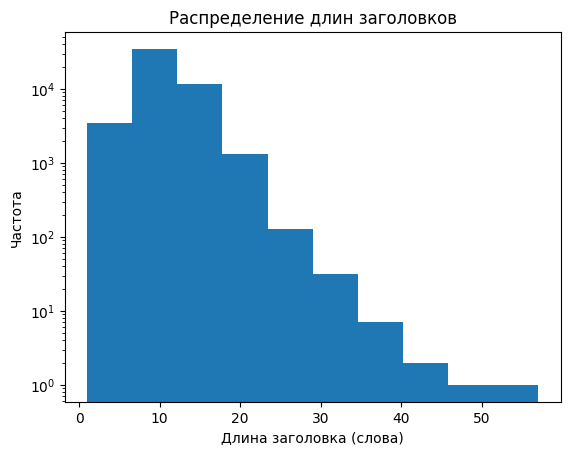

Медиана: 10.0
Срденее: 10.754416754416754


In [6]:
title_len_words = df["Title"].astype(str).apply(lambda x: len(x.split()))

plt.figure()
plt.hist(title_len_words, bins=10)
plt.yscale("log")
plt.xlabel("Длина заголовка (слова)")
plt.ylabel("Частота")
plt.title("Распределение длин заголовков")
plt.show()

print(f'Медиана: {title_len_words.median()}')
print(f'Срденее: {title_len_words.mean()}')

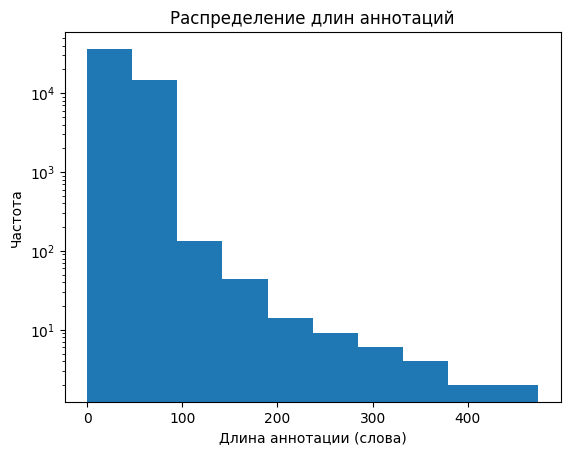

Медиана: 24.0
Срденее: 34.29331929331929


In [7]:
text_len_words = df["Abstract"].astype(str).apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt

plt.figure()
plt.hist(text_len_words, bins=10)
plt.yscale("log")
plt.xlabel("Длина аннотации (слова)")
plt.ylabel("Частота")
plt.title("Распределение длин аннотаций")
plt.show()

print(f'Медиана: {text_len_words.median()}')
print(f'Срденее: {text_len_words.mean()}')

In [8]:
df['Category'].value_counts()

Category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

In [9]:
df["text"] = df["Title"] + " <SEP> " + df["Abstract"]

In [10]:
df_behavior = pd.read_csv('behaviors.tsv', sep='\t', header=None,
    names=["Impression ID", "User ID", "Time", "History", "Impressions"])

In [11]:
df_behavior.info()

<class 'pandas.DataFrame'>
RangeIndex: 156965 entries, 0 to 156964
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Impression ID  156965 non-null  int64
 1   User ID        156965 non-null  str  
 2   Time           156965 non-null  str  
 3   History        153727 non-null  str  
 4   Impressions    156965 non-null  str  
dtypes: int64(1), str(4)
memory usage: 6.0 MB


In [12]:
df_behavior = df_behavior.dropna()
df_behavior.info()

<class 'pandas.DataFrame'>
Index: 153727 entries, 0 to 156964
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Impression ID  153727 non-null  int64
 1   User ID        153727 non-null  str  
 2   Time           153727 non-null  str  
 3   History        153727 non-null  str  
 4   Impressions    153727 non-null  str  
dtypes: int64(1), str(4)
memory usage: 7.0 MB


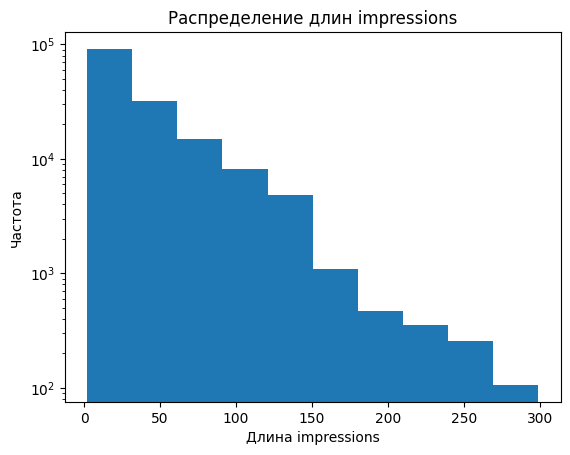

Медиана: 24.0
Среднее: 37.228346354251364
Максимум: 299
75-й перцентиль: 51.0


In [13]:
candidates_len = df_behavior["Impressions"].astype(str).apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt

plt.figure()
plt.hist(candidates_len, bins=10)
plt.yscale("log")
plt.xlabel("Длина impressions")
plt.ylabel("Частота")
plt.title("Распределение длин impressions")
plt.show()

print(f"Медиана: {candidates_len.median()}")
print(f"Среднее: {candidates_len.mean()}")
print(f"Максимум: {candidates_len.max()}")
print(f"75-й перцентиль: {candidates_len.quantile(0.75)}")

## BASELINE

### all-MiniLM-L6-v2 + cos sim + mean user history emb

In [13]:
from sentence_transformers import SentenceTransformer

model_allMiniLM = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

news_embeddings = model_allMiniLM.encode(
    df["text"].tolist(),
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

tokenized_news = {
    news_id: emb
    for news_id, emb in zip(df["News ID"], news_embeddings)}

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\turyan\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\turyan\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/802 [00:00<?, ?it/s]

In [14]:
def parse_impressions(impression_str):
    items = impression_str.split()

    news_ids = []
    labels = []

    for item in items:
        nid, label = item.split("-")
        news_ids.append(nid)
        labels.append(int(label))

    return news_ids, labels

def get_user_embedding(history_ids, tokenized_news):
    embs = [
        tokenized_news[nid]
        for nid in history_ids
        if nid in tokenized_news
    ]

    if len(embs) == 0:
        return None

    user_emb = np.mean(embs, axis=0)

    user_emb = user_emb / (np.linalg.norm(user_emb) + 1e-12)

    return user_emb

def score_candidates(user_emb, candidate_ids, tokenized_news):
    scores = []

    for nid in candidate_ids:
        cand_emb = tokenized_news[nid]

        score = float(np.dot(user_emb, cand_emb))
        scores.append(score)

    return scores

def rank_behavior_row(row, tokenized_news):
    history_ids = str(row["History"]).split()
    candidate_ids, labels = parse_impressions(row["Impressions"])

    user_emb = get_user_embedding(history_ids, tokenized_news)

    if user_emb is None:
        scores = [0.0] * len(candidate_ids)
    else:
        scores = score_candidates(
            user_emb,
            candidate_ids,
            tokenized_news
        )

    return candidate_ids, labels, scores


from sklearn.metrics import roc_auc_score

def compute_auc(all_labels, all_scores):
    aucs = []

    for labels, scores in zip(all_labels, all_scores):
        if len(set(labels)) < 2:
            continue

        auc = roc_auc_score(labels, scores)
        aucs.append(auc)

    return np.mean(aucs)

In [15]:
def BaselinePipelineEval(iterations=15000):
    all_labels = []
    all_scores = []

    n = min(iterations, len(df_behavior))

    for row in tqdm(range(n)):
        cand_ids, labels, scores = rank_behavior_row(
            df_behavior.iloc[row],
            tokenized_news
        )

        all_labels.append(labels)
        all_scores.append(scores)

    return compute_auc(all_labels, all_scores)

In [16]:
auc = BaselinePipelineEval(15000)
print("AUC: ", auc)

100%|██████████████████████████████████████████████████████████████████████████| 15000/15000 [00:04<00:00, 3554.63it/s]


AUC:  0.6284747360245334


#### AUC: 0.625-0.628

In [17]:
import numpy as np
import pandas as pd

def sample_sports_similarity(
    df,
    tokenized_news,
    n=5,
    category = 'sports',
    random_state=None
):
    category_col="Category"
    subcategory_col="SubCategory"
    title_col="Title"
    id_col="News ID"

    sports_df = df[df[category_col].str.lower() == category].copy()

    sampled = sports_df.sample(n=n, random_state=random_state)

    print("Sampled news:\n")
    for _, row in sampled.iterrows():
        print(f"News ID: {row[id_col]}")
        print(f"Title: {row[title_col]}")
        print(f"SubCategory: {row[subcategory_col]}")
        print("-" * 80)

    ids = sampled[id_col].tolist()

    print("\nPairwise similarities:\n")

    similarities = []

    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            id1, id2 = ids[i], ids[j]

            emb1 = tokenized_news[id1]
            emb2 = tokenized_news[id2]

            sim = float(np.dot(emb1, emb2))

            similarities.append({
                "news_id_1": id1,
                "news_id_2": id2,
                "similarity": sim,
                "title_1": sampled[sampled[id_col] == id1][title_col].iloc[0],
                "title_2": sampled[sampled[id_col] == id2][title_col].iloc[0],
            })

            print(f"{id1} ↔ {id2}: {sim:.4f}")

    return

In [18]:
sample_sports_similarity(
    df,
    tokenized_news,
    n=3,
    category = 'sports'
)

Sampled news:

News ID: N6006
Title: 49ers' Jimmy Garoppolo salvages a mediocre day with a strong second half
SubCategory: football_nfl
--------------------------------------------------------------------------------
News ID: N53382
Title: Watch Phil Mickelson come THIS close to making a hole-in-one on a par 4
SubCategory: golf
--------------------------------------------------------------------------------
News ID: N28367
Title: Roy scores first career NHL goal, Vegas tops Anaheim 5-2
SubCategory: icehockey_nhl
--------------------------------------------------------------------------------

Pairwise similarities:

N6006 ↔ N53382: 0.1420
N6006 ↔ N28367: 0.1009
N53382 ↔ N28367: 0.3121


## TOKENIZATION

In [14]:
from transformers import AutoTokenizer
import torch

TOKENIZER_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL_NAME)

In [15]:
MAX_SEQ_LEN = 128

tokenized_news = {}

for _, row in df.iterrows():
    news_id = row["News ID"]
    text = row["text"]

    if not isinstance(text, str):
        text = ""

    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_SEQ_LEN,
        return_tensors="pt"
    )

    tokenized_news[news_id] = {
        "input_ids": enc["input_ids"].squeeze(0).long(),
        "attention_mask": enc["attention_mask"].squeeze(0).long()
    }

In [16]:
some_id = next(iter(tokenized_news.keys()))

input_ids = tokenized_news[some_id]["input_ids"]
attention_mask = tokenized_news[some_id]["attention_mask"]

print("News ID:", some_id)
print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)

print("\nFirst 20 input_ids:")
print(input_ids[:20])

print("\nFirst 20 attention_mask:")
print(attention_mask[:20])

tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())

print("\nFirst 20 tokens:")
print(tokens[:20])

News ID: N55528
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])

First 20 input_ids:
tensor([  101,  1996,  9639,  3035,  3870,  1010,  3159,  2798,  1010,  1998,
         3159,  5170,  8415,  2011,  1026, 19802,  1028,  4497,  1996, 14960])

First 20 attention_mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

First 20 tokens:
['[CLS]', 'the', 'brands', 'queen', 'elizabeth', ',', 'prince', 'charles', ',', 'and', 'prince', 'philip', 'swear', 'by', '<', 'sep', '>', 'shop', 'the', 'notebook']


## EMBEDDINGS

In [17]:
class AllMiniLMEmbedding(nn.Module):
    def __init__(self,normalize=True):
        super().__init__()
        
        model_name="sentence-transformers/all-MiniLM-L6-v2"

        self.auto_model = AutoModel.from_pretrained(model_name)
        self.normalize = normalize
        hidden_dim = self.auto_model.config.hidden_size  # 384 

        for param in self.auto_model.parameters():
            param.requires_grad = False

        self.auto_model.eval()



    def mean_pooling(self, token_embeddings, attention_mask):
    
        mask = attention_mask.unsqueeze(-1).float()
        # [B*N, L, 1]

        summed = torch.sum(token_embeddings * mask, dim=1)
        # [B*N, D]

        counts = mask.sum(dim=1).clamp(min=1e-9)
        # [B*N, 1]

        pooled = summed / counts
        # [B*N, D]

        return pooled

    def forward(self, input_ids, attention_mask):

        if input_ids.dim() != 3:
            raise ValueError(f"input_ids must be [B, N, L], got {input_ids.shape}")

        if attention_mask.dim() != 3:
            raise ValueError(
                f"attention_mask must be [B, N, L], got {attention_mask.shape}"
            )

        B, N, L = input_ids.shape

        flat_input_ids = input_ids.reshape(B * N, L)
        flat_attention_mask = attention_mask.reshape(B * N, L)

        
        with torch.no_grad():
            outputs = self.auto_model(
                input_ids=flat_input_ids,
                attention_mask=flat_attention_mask
            )

            token_embeddings = outputs.last_hidden_state
            # [B*N, L, 384]

        sentence_emb = self.mean_pooling(token_embeddings,flat_attention_mask)
        
        # [B*N, 384]

        if self.normalize:
            sentence_emb = F.normalize(sentence_emb, p=2, dim=-1)

        sentence_emb = sentence_emb.reshape(B, N, -1)
        # [B, N, 384]

        return sentence_emb

In [18]:
def precompute_news_embeddings(
    tokenized_news,
    text_encoder,
    device,
    batch_size=128
):
   
    text_encoder = text_encoder.to(device)
    text_encoder.eval()

    news_ids = list(tokenized_news.keys())

    all_input_ids = torch.stack([
        tokenized_news[nid]["input_ids"]
        for nid in news_ids
    ])
    # [num_news, L]

    all_attention_mask = torch.stack([
        tokenized_news[nid]["attention_mask"]
        for nid in news_ids
    ])
    # [num_news, L]

    dataset = TensorDataset(all_input_ids, all_attention_mask)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    all_embeddings = []

    with torch.no_grad():
        for input_ids, attention_mask in tqdm(loader):
            input_ids = input_ids.to(device, non_blocking=True)
            attention_mask = attention_mask.to(device, non_blocking=True)

            # AllMiniLMEmbedding ждёт [B, N, L]
            input_ids = input_ids.unsqueeze(1)
            attention_mask = attention_mask.unsqueeze(1)

            emb = text_encoder(input_ids, attention_mask)
            # [B, 1, 384]

            emb = emb.squeeze(1)
            # [B, 384]

            emb = F.normalize(emb, p=2, dim=-1)
            # на всякий случай

            all_embeddings.append(emb.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    # [num_news, 384]

    news_id_to_emb = {
        news_id: all_embeddings[i]
        for i, news_id in enumerate(news_ids)
    }

    return news_id_to_emb

In [19]:
text_encoder = AllMiniLMEmbedding().to(device)

news_id_to_emb = precompute_news_embeddings(
    tokenized_news=tokenized_news,
    text_encoder=text_encoder,
    device=device,
    batch_size=128
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  0%|          | 0/401 [00:00<?, ?it/s]

## DATA LOADER

### Dataset prep

In [20]:
import random
from torch.utils.data import Dataset


class NewsRecEmbeddingDataset(Dataset):
    def __init__(
        self,
        behaviors_df,
        news_id_to_emb,
        history_size=50,
        negative_num=4
    ):
        self.behaviors_df = behaviors_df.reset_index(drop=True)
        self.news_id_to_emb = news_id_to_emb
        self.history_size = history_size
        self.negative_num = negative_num

        first_emb = next(iter(news_id_to_emb.values()))
        self.embed_dim = first_emb.shape[-1]

        self.examples = self._build_examples()

    def _build_examples(self):
        examples = []

        for _, row in self.behaviors_df.iterrows():
            history = row["History"]
            impressions = row["Impressions"]

            if not isinstance(history, str) or not isinstance(impressions, str):
                continue

            history_ids = [
                nid for nid in history.split()
                if nid in self.news_id_to_emb
            ]

            if len(history_ids) == 0:
                continue

            positives = []
            negatives = []

            for item in impressions.split():
                news_id, label = item.rsplit("-", 1)

                if news_id not in self.news_id_to_emb:
                    continue

                if label == "1":
                    positives.append(news_id)
                elif label == "0":
                    negatives.append(news_id)

            if len(positives) == 0 or len(negatives) == 0:
                continue

            for pos_id in positives:
                examples.append({
                    "history": history_ids,
                    "positive": pos_id,
                    "negatives": negatives
                })

        return examples

    def __len__(self):
        return len(self.examples)

    def _pad_history(self, history_ids):
        history_ids = history_ids[-self.history_size:]

        pad_len = self.history_size - len(history_ids)
        padded_history = ["<PAD_NEWS>"] * pad_len + history_ids

        emb_list = []
        mask_list = []

        for news_id in padded_history:
            if news_id == "<PAD_NEWS>":
                emb = torch.zeros(self.embed_dim, dtype=torch.float32)
                mask = 0
            else:
                emb = self.news_id_to_emb[news_id].float()
                mask = 1

            emb_list.append(emb)
            mask_list.append(mask)

        history_emb = torch.stack(emb_list)
        # [H, 384]

        history_mask = torch.tensor(mask_list, dtype=torch.long)
        # [H]

        return history_emb, history_mask

    def _sample_candidates(self, positive_id, negative_ids):
        if len(negative_ids) >= self.negative_num:
            sampled_negatives = random.sample(negative_ids, self.negative_num)
        else:
            sampled_negatives = random.choices(
                negative_ids,
                k=self.negative_num
            )

        candidates = [positive_id] + sampled_negatives
        random.shuffle(candidates)

        label = candidates.index(positive_id)

        candidate_emb = torch.stack([
            self.news_id_to_emb[nid].float()
            for nid in candidates
        ])
        # [C, 384]

        label = torch.tensor(label, dtype=torch.long)

        return candidate_emb, label

    def __getitem__(self, idx):
        example = self.examples[idx]

        history_emb, history_mask = self._pad_history(example["history"])

        candidate_emb, label = self._sample_candidates(
            example["positive"],
            example["negatives"]
        )

        return {
            "history_emb": history_emb,        # [H, 384]
            "history_mask": history_mask,      # [H]
            "candidate_emb": candidate_emb,    # [C, 384]
            "label": label
        }

### Split data

In [21]:
from sklearn.model_selection import train_test_split

train_behaviors_df, test_behaviors_df = train_test_split(
    df_behavior,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [38]:
HISTORY_SIZE = 50
NEGATIVE_NUM = 4

BATCH_SIZE = 64

train_dataset = NewsRecEmbeddingDataset(
    behaviors_df=train_behaviors_df,
    news_id_to_emb=news_id_to_emb,
    history_size=HISTORY_SIZE,
    negative_num=NEGATIVE_NUM
)

test_dataset = NewsRecEmbeddingDataset(
    behaviors_df=test_behaviors_df,
    news_id_to_emb=news_id_to_emb,
    history_size=HISTORY_SIZE,
    negative_num=NEGATIVE_NUM
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("train examples:", len(train_dataset))
print("test examples:", len(test_dataset))

train examples: 184854
test examples: 46676


In [39]:
batch = next(iter(train_loader))

print(batch["history_emb"].shape)
print(batch["history_mask"].shape)
print(batch["candidate_emb"].shape)
print(batch["label"].shape)

torch.Size([64, 50, 384])
torch.Size([64, 50])
torch.Size([64, 5, 384])
torch.Size([64])


## BUILDING BLOCKS

In [24]:
import torch.nn.functional as F

class AttentionPooling(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.proj = nn.Linear(embed_dim, embed_dim) #матрица важности признаков
        self.context = nn.Linear(embed_dim, 1, bias=False) #преобразуем признаки в скаляр

    def forward(self, x, attention_mask=None):
        scores = self.context(torch.tanh(self.proj(x))).squeeze(-1)

        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask == 0, -1e9)

        weights = F.softmax(scores, dim=1)

        pooled = torch.sum(x * weights.unsqueeze(-1), dim=1)

        return pooled

In [25]:
class NewsTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.ln2 = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, attention_mask=None):
        x_norm = self.ln1(x)

        key_padding_mask = None
        if attention_mask is not None:
            key_padding_mask = attention_mask == 0


        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )

        x = x + attn_out

        x_norm = self.ln2(x)
        ffn_out = self.ffn(x_norm)

        x = x + ffn_out

        return x


In [26]:
def cosine_score(user_emb, candidate_emb):
    # [B, C]
    return torch.sum(user_emb.unsqueeze(1) * candidate_emb, dim=-1)

## Custom Model

![Alt](news_rec.png)

![Alt](user_emb.png)

### History embedding block

In [27]:
class HistoryEmbeddingBlockFromEmb(nn.Module):
    def __init__(
        self,
        history_size,
        news_dim=384,
        num_heads=8,
        ffn_dim=1024,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        self.position_embedding = nn.Embedding(history_size, news_dim)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            NewsTransformerBlock(
                embed_dim=news_dim,
                num_heads=num_heads,
                ffn_dim=ffn_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.pooling = AttentionPooling(news_dim)

    def forward(self, history_emb, history_mask):
        B, H, D = history_emb.shape

        positions = torch.arange(H, device=history_emb.device)
        positions = positions.unsqueeze(0).expand(B, H)

        x = history_emb + self.position_embedding(positions)
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x, attention_mask=history_mask)

        user_emb = self.pooling(x, attention_mask=history_mask)
        user_emb = F.normalize(user_emb, p=2, dim=-1)

        return user_emb

### Model

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class NewsRecModelProjectionMLP(nn.Module):
    def __init__(
        self,
        history_encoder,
        embed_dim=384,
        proj_dim=384,
        scorer_hidden_dim=256,
        dropout=0.1
    ):
        super().__init__()

        PAIR_FEATURES = 4

        self.news_proj = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, proj_dim)
        )

        self.history_encoder = history_encoder

        self.scorer = nn.Sequential(
            nn.Linear(proj_dim * PAIR_FEATURES, scorer_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(scorer_hidden_dim, 1)
        )

    def forward(self, history_emb, history_mask, candidate_emb):
        """
        history_emb:   [B, H, 384]
        history_mask:  [B, H]
        candidate_emb: [B, C, 384]

        returns:
            scores: [B, C]
        """

        # 1. Projection для history newso
        history_emb = self.news_proj(history_emb)
        # [B, H, D]

        # 2. Projection для candidate news
        candidate_emb = self.news_proj(candidate_emb)
        # [B, C, D]

        # 3. User representation из истории
        user_emb = self.history_encoder(history_emb, history_mask)
        # [B, D]

        user_emb = F.normalize(user_emb, p=2, dim=-1)
        candidate_emb = F.normalize(candidate_emb, p=2, dim=-1)

        B, C, D = candidate_emb.shape

        # 4. Копируем user_emb для каждого candidate
        user_expanded = user_emb.unsqueeze(1).expand(B, C, D)
        # [B, C, D]

        # 5. Признаки пары user-news
        pair_features = torch.cat(
            [
                user_expanded,
                candidate_emb,
                user_expanded * candidate_emb,
                torch.abs(user_expanded - candidate_emb)
            ],
            dim=-1
        )
        # [B, C, D * 4]

        # 6. MLP scorer
        scores = self.scorer(pair_features).squeeze(-1)
        # [B, C]

        return scores

### Train

In [31]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_examples = 0

    for batch in tqdm(dataloader):
        history_emb = batch["history_emb"].to(device, non_blocking=True)
        history_mask = batch["history_mask"].to(device, non_blocking=True)
        candidate_emb = batch["candidate_emb"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        scores = model(
            history_emb=history_emb,
            history_mask=history_mask,
            candidate_emb=candidate_emb
        )
        # [B, C]

        loss = F.cross_entropy(scores, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples

In [40]:
NEWS_PROJECTION_DIM = 384

history_encoder = HistoryEmbeddingBlockFromEmb(
    history_size=HISTORY_SIZE,
    news_dim=NEWS_PROJECTION_DIM,
    num_heads=12,
    ffn_dim=1024,
    num_layers=3,
    dropout=0.1
)

model = NewsRecModelProjectionMLP(
    history_encoder=history_encoder,
    embed_dim=384,
    proj_dim=NEWS_PROJECTION_DIM,
    scorer_hidden_dim=256,
    dropout=0.1
)

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.5e-4,
    weight_decay=1e-5
)

num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device
    )

    print(f"Epoch {epoch + 1}/{num_epochs} | train loss: {train_loss:.4f}")

  0%|          | 0/2889 [00:00<?, ?it/s]

Epoch 1/5 | train loss: 1.4660


  0%|          | 0/2889 [00:00<?, ?it/s]

Epoch 2/5 | train loss: 1.4343


  0%|          | 0/2889 [00:00<?, ?it/s]

Epoch 3/5 | train loss: 1.4281


  0%|          | 0/2889 [00:00<?, ?it/s]

Epoch 4/5 | train loss: 1.4224


  0%|          | 0/2889 [00:00<?, ?it/s]

Epoch 5/5 | train loss: 1.4184


### Test

In [41]:
def evaluate_loss_group_auc_from_emb(model, dataloader, device):
    """
    Evaluation для negative sampling setup:
        loss = CrossEntropyLoss
        AUC = mean group AUC по каждому candidate set

    Batch:
        history_emb:   [B, H, 384]
        history_mask:  [B, H]
        candidate_emb: [B, C, 384]
        label:         [B]
    """

    model.eval()

    total_loss = 0.0
    total_examples = 0

    aucs = []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            history_emb = batch["history_emb"].to(device, non_blocking=True)
            history_mask = batch["history_mask"].to(device, non_blocking=True)
            candidate_emb = batch["candidate_emb"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            scores = model(
                history_emb=history_emb,
                history_mask=history_mask,
                candidate_emb=candidate_emb
            )
            # [B, C]

            loss = F.cross_entropy(scores, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_examples += batch_size

            scores_np = scores.detach().cpu().numpy()
            labels_np = labels.detach().cpu().numpy()

            B, C = scores_np.shape

            for i in range(B):
                y_true = np.zeros(C, dtype=np.int64)
                y_true[labels_np[i]] = 1

                y_score = scores_np[i]

                auc = roc_auc_score(y_true, y_score)
                aucs.append(auc)

    avg_loss = total_loss / total_examples
    avg_auc = float(np.mean(aucs))

    return avg_loss, avg_auc

In [42]:
test_loss, test_auc = evaluate_loss_group_auc_from_emb(
        model=model,
        dataloader=test_loader,
        device=device
    )

print(f"test loss: {test_loss:.4f}")
print(f"test AUC: {test_auc:.4f}")

  0%|          | 0/730 [00:00<?, ?it/s]

test loss: 1.4255
test AUC: 0.6853
